# 圆周运动的两种坐标画法：极坐标网格 vs 直角化 $(r, \theta)$ 平面

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月21日

同一对函数

$$
r(t) = R, \qquad \theta(t) = \omega_0 t \quad (\text{匀速圆周运动})
$$

可以画在两种"坐标纸"上：

**极坐标网格（同心圆网格）**：画在物理平面上，网格线是同心圆（$r = \text{const}$）与射线（$\theta = \text{const}$）。运动是一个圆，质点位置为 $(r\cos\theta,\ r\sin\theta)$；动力学方程含 $r\dot\theta^2$、$2v_r\dot\theta$ 等弯曲项（上一例用前向欧拉法求解过：圆轨道恰为更新映射的不动点，数值解精确贴圆）。

**直角化 $(r, \theta)$ 平面**：把数对 $(r, \theta)$ 直接当作平面直角坐标——横轴 $r$、纵轴 $\theta$，网格是方格纸。同一个运动画在这张纸上：横坐标不动（$r \equiv R$）、纵坐标匀速上升（$\theta = \omega_0 t$）。它不再是物理平面，只是记录 $r$、$\theta$ 随时间演化的"账本"，但网格结构一目了然。

**运行之前，先把你的预测写下来**：

1. 在方格平面上，$r(t) = R$、$\theta(t) = \omega_0 t$ 的图像是什么形状？
2. 方格平面的竖直线（$r = \text{const}$）与水平线（$\theta = \text{const}$），映射回同心圆网格各对应什么？
3. 前向欧拉的数值解画在两种画布上，都精确吗？精确的原因相同吗？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_polar(h, n_steps, r0, th0, vr0, thd0, w_sq=0.0):
    """极坐标前向欧拉：状态 (r, theta, vr, theta_dot)，右端全部用旧值
    w_sq = omega0**2 时为各向同性振子力 -k r；w_sq = 0 为自由质点（不受力）"""
    r   = np.zeros(n_steps + 1); th  = np.zeros(n_steps + 1)
    vr  = np.zeros(n_steps + 1); thd = np.zeros(n_steps + 1)
    r[0], th[0], vr[0], thd[0] = r0, th0, vr0, thd0
    for n in range(n_steps):
        r[n+1]   = r[n]  + h * vr[n]
        vr[n+1]  = vr[n] + h * (r[n] * thd[n]**2 - w_sq * r[n])
        th[n+1]  = th[n] + h * thd[n]
        thd[n+1] = thd[n] - h * 2.0 * vr[n] * thd[n] / r[n]
    return r, th, vr, thd


# ---------- 参数：匀速圆周运动 ----------
m, k = 1.0, 1.0
omega0 = np.sqrt(k / m)
R = 1.0
h = 0.05                # 时间步长 (s)
t_end = 4 * np.pi       # 总时间：整整 2 圈
n_steps = int(t_end / h)
t = np.arange(n_steps + 1) * h

# 数值解（极坐标前向欧拉）与精确解
r_n, th_n, vr_n, thd_n = forward_euler_polar(h, n_steps, R, 0.0, 0.0, omega0, w_sq=omega0**2)
r_ex, th_ex = R + np.zeros_like(t), omega0 * t

print(f'圆轨道：max|r - R| = {np.abs(r_n - R).max():.2e} m')
print(f'每步转角 = h·θ̇ = {h * omega0:.4f} rad（精确解每步同样转过此角）')
print(f'数值末角 - 精确末角 = {th_n[-1] - th_ex[-1]:.2e} rad')

圆轨道：max|r - R| = 0.00e+00 m
每步转角 = h·θ̇ = 0.0500 rad（精确解每步同样转过此角）
数值末角 - 精确末角 = 4.26e-14 rad


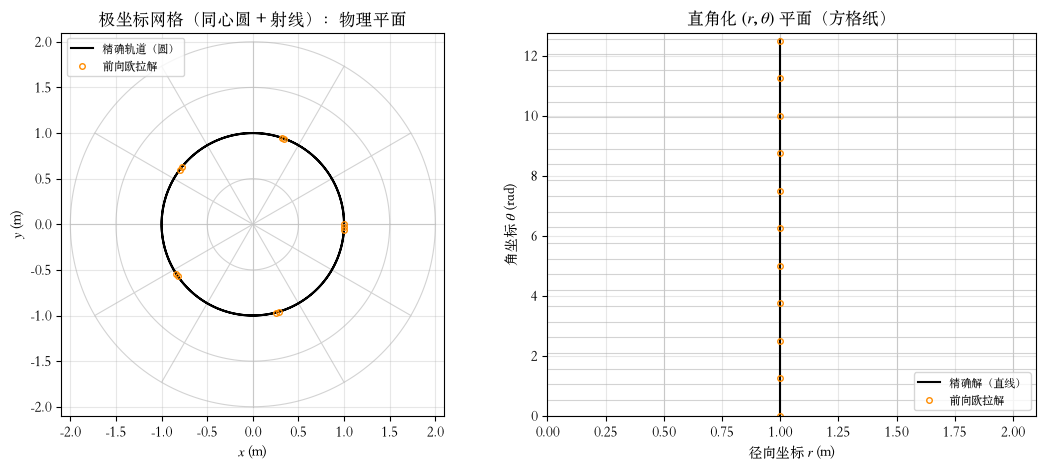

In [3]:
# ---------- 图 1：圆轨道的两种画布 ----------
def draw_polar_grid(ax, radii, n_rays, r_max):
    """同心圆 + 射线网格"""
    ang = np.linspace(0, 2 * np.pi, 200)
    for r_g in radii:
        ax.plot(r_g * np.cos(ang), r_g * np.sin(ang), color='lightgray', lw=0.8, zorder=0)
    for i in range(n_rays):
        a = 2 * np.pi * i / n_rays
        ax.plot([0, r_max * np.cos(a)], [0, r_max * np.sin(a)], color='lightgray', lw=0.8, zorder=0)


def draw_square_grid(ax, r_ticks, th_ticks, r_max, th_max):
    """方格网格：竖线 r=const，横线 θ=const"""
    for r_g in r_ticks:
        ax.axvline(r_g, color='lightgray', lw=0.8, zorder=0)
    for th_g in th_ticks:
        ax.axhline(th_g, color='lightgray', lw=0.8, zorder=0)


fig1, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.8))

# (a) 极坐标网格（物理平面）
ax = axA
draw_polar_grid(ax, radii=[0.5, 1.0, 1.5, 2.0], n_rays=12, r_max=2.0)
ax.plot(R * np.cos(th_ex), R * np.sin(th_ex), 'k-', lw=1.5, label='精确轨道（圆）')
ax.plot(r_n * np.cos(th_n), r_n * np.sin(th_n), 'o', ms=4, mfc='none',
        color='darkorange', markevery=25, label='前向欧拉解')
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('极坐标网格（同心圆 + 射线）：物理平面')
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.1, 2.1)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (b) 直角化 (r, θ) 平面（方格纸）
ax = axB
draw_square_grid(ax, r_ticks=[0.5, 1.0, 1.5, 2.0],
                 th_ticks=np.arange(0, 4 * np.pi + 0.1, np.pi / 6),
                 r_max=2.0, th_max=4 * np.pi)
ax.plot(r_ex, th_ex, 'k-', lw=1.5, label='精确解（直线）')
ax.plot(r_n, th_n, 'o', ms=4, mfc='none', color='darkorange',
        markevery=25, label='前向欧拉解')
ax.set_xlabel('径向坐标 $r$ (m)')
ax.set_ylabel('角坐标 $\\theta$ (rad)')
ax.set_title('直角化 $(r, \\theta)$ 平面（方格纸）')
ax.set_xlim(0, 2.1)
ax.set_ylim(0, 4 * np.pi + 0.2)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig1.savefig('outputs/2_polar_vs_rectangular_euler_grid.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 检验你的预测

- 方格平面上，解是什么形状？与同心圆那侧的圆轨道是**同一条曲线**吗？
- 竖直线 $r = \text{const}$ 对应同心圆网格里的什么？水平线 $\theta = \text{const}$ 呢？（提示：数一数各自的条数。）
- 欧拉解的点：在物理平面上相邻两点间隔什么相等？在方格平面上呢？

直线轨道：最近距离精确值 p = 0.500 m，数值解 r 最小值 = 0.500 m
末点位置：数值 (-2.0000, 0.4993) vs 精确 (-2.0000, 0.5000) m


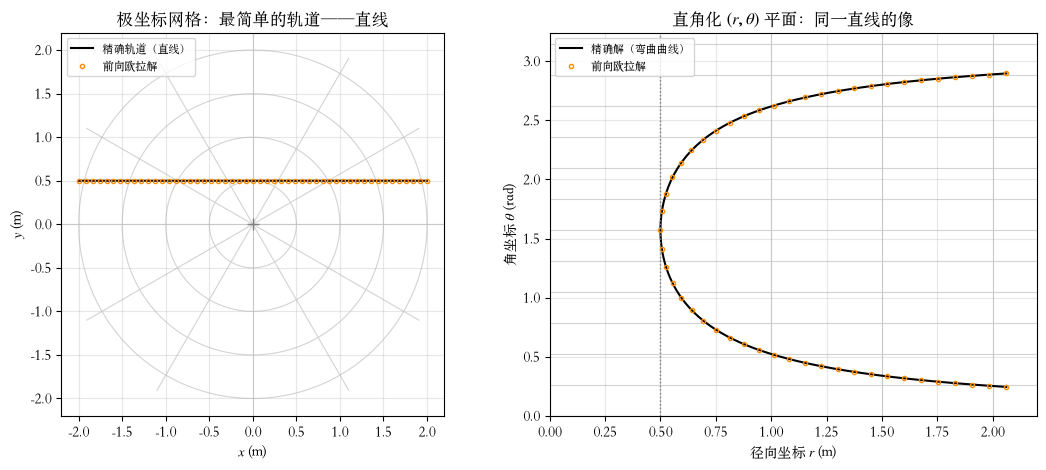

In [4]:
# ---------- 图 2：匀速直线运动（自由质点，不受力）的两种画布 ----------
p_imp = 0.5             # 直线到原点的最近距离（瞄准距离，m）
v_speed = 1.0           # 速率 (m/s)
x_start = 2.0           # 从 (x_start, p) 出发沿 -x 方向运动
t3_end = 2 * x_start / v_speed   # 恰好走到 (-x_start, p)
h3 = 0.0002
n3 = int(t3_end / h3)
t3 = np.arange(n3 + 1) * h3

# 精确解：x = x_start - v·t，y = p（直线不经过原点）
x_l = x_start - v_speed * t3
y_l = np.full_like(t3, p_imp)
r_l = np.hypot(x_l, y_l)
th_l = np.arctan2(y_l, x_l)

# 极坐标前向欧拉（自由质点：w_sq = 0）
r0_l = r_l[0]
th0_l = np.arctan2(y_l[0], x_l[0])
vr0_l = (x_l[0] * (-v_speed)) / r0_l
thd0_l = (x_l[0] * 0.0 - y_l[0] * (-v_speed)) / r0_l**2
r3, th3, vr3, thd3 = forward_euler_polar(h3, n3, r0_l, th0_l, vr0_l, thd0_l)

print(f'直线轨道：最近距离精确值 p = {p_imp:.3f} m，数值解 r 最小值 = {r3.min():.3f} m')
print(f'末点位置：数值 ({r3[-1] * np.cos(th3[-1]):.4f}, {r3[-1] * np.sin(th3[-1]):.4f})'
      f' vs 精确 ({-x_start:.4f}, {p_imp:.4f}) m')

fig2, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.8))

# (a) 极坐标网格（物理平面）：直线
ax = axA
draw_polar_grid(ax, radii=[0.5, 1.0, 1.5, 2.0], n_rays=12, r_max=2.2)
ax.plot(x_l, y_l, 'k-', lw=1.5, label='精确轨道（直线）')
ax.plot(r3 * np.cos(th3), r3 * np.sin(th3), 'o', ms=3, mfc='none',
        color='darkorange', markevery=400, label='前向欧拉解')
ax.plot(0, 0, '+', color='gray', ms=8)
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('极坐标网格：最简单的轨道——直线')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (b) 直角化 (r, θ) 平面（方格纸）：同一直线的像
ax = axB
draw_square_grid(ax, r_ticks=[0.5, 1.0, 1.5, 2.0],
                 th_ticks=np.arange(0, np.pi + 0.1, np.pi / 12),
                 r_max=2.2, th_max=np.pi)
ax.plot(r_l, th_l, 'k-', lw=1.5, label='精确解（弯曲曲线）')
ax.plot(r3, th3, 'o', ms=3, mfc='none', color='darkorange',
        markevery=400, label='前向欧拉解')
ax.axvline(p_imp, color='gray', ls=':', lw=1.0)
ax.set_xlabel('径向坐标 $r$ (m)')
ax.set_ylabel('角坐标 $\\theta$ (rad)')
ax.set_title('直角化 $(r, \\theta)$ 平面：同一直线的像')
ax.set_xlim(0, 2.2)
ax.set_ylim(0, np.pi + 0.1)
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig2.savefig('outputs/2_polar_vs_rectangular_euler_line.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 为什么两种画法都对

两种画布画的是**同一对函数** $r(t)$、$\theta(t)$，区别只在"纸"的网格：

| | 极坐标网格（物理平面） | 直角化 $(r,\theta)$ 平面（账本） |
| ---- | ---- | ---- |
| 网格线 | 同心圆（$r=\text{const}$）、射线（$\theta=\text{const}$） | 竖直线（$r=\text{const}$）、水平线（$\theta=\text{const}$） |
| 圆轨道的像 | 圆 | 水平直线 |
| 直线轨道的像 | 直线 | 弯曲曲线（$r$ 先减后增） |
| 欧拉步长 | 等角 $h\dot\theta$ | 等距 $h\dot\theta$（竖直方向） |

对圆轨道，两种画布上欧拉解都精确，但原因不同：

- **物理平面**：圆轨道是极坐标更新映射的**不动点**——$r\dot\theta^2$ 与 $\omega_0^2 r$ 平衡，$r$、$v_r$、$\dot\theta$ 都不变（上一例的结论）。
- **方格平面**：精确解是**匀速直线运动**，每步等距前进——匀速直线运动正是任何显式单步格式都能精确描述的最简单情形。

图 2 的匀速直线运动（自由质点，$F=0$）展示了硬币的另一面：直线在物理平面上是"最简单"的轨道，但在极坐标更新格式里它**不是**不动点，欧拉解出现漂移；同一条直线若改用直角坐标 $(x, y)$ 描述，每步都是精确的。**坐标不仅改变运动的图像，也改变数值误差的行为。**

要注意：直角化平面只是记录 $(r,\theta)$ 的"账本"，不是物理空间。物理平面的度量是 $ds^2 = dr^2 + r^2\,d\theta^2$（角度方向的弧长是 $r\,d\theta$，这正是同心圆越外越大的原因），方格纸把它画成了 $ds^2 = dr^2 + d\theta^2$——读图时要记住这张"纸"被人为拉直了。

## 结论与思考

- 同一匀速圆周运动 $r(t)=R$、$\theta(t)=\omega_0 t$：画在同心圆网格上是**圆**，画在方格平面上是**水平直线**——运动本身没变，变的是记录它的网格。
- 网格映射：方格竖线 $r=\text{const}$ ↔ 同心圆，方格横线 $\theta=\text{const}$ ↔ 射线。
- 前向欧拉在两种画布上都精确：物理平面上靠**不动点**，方格平面上靠**匀速直线的等距推进**。
- 匀速直线运动：物理平面上是"最简单"的直线，方格平面上反而是弯曲曲线；它在极坐标里的欧拉解有漂移，换成直角坐标 $(x,y)$ 则每步精确——"简单"与"精确"都依赖于坐标画法。

**思考**：

1. 若把方格平面的横轴换成 $\ln r$，同心圆网格会被怎样"拉直"？哪些网格线不变？
2. 不过原点的直线在极坐标里满足 $r\cos(\theta - \theta_0) = p$（$p$ 为原点到直线的距离）。试着推导，并用它解释方格平面上那条曲线为什么 $r$ 先减后增、关于 $\theta = \pi/2$ 对称。
3. 挑一种"让运动看起来最简单"的坐标画法：对圆，方格平面把它变成直线。对自由落体、对单摆，你会挑什么坐标、得到什么形状？